            Passengers       12-MA
Month                             
1949-01-01         112         NaN
1949-02-01         118         NaN
1949-03-01         132         NaN
1949-04-01         129         NaN
1949-05-01         121         NaN
1949-06-01         135         NaN
1949-07-01         148         NaN
1949-08-01         148         NaN
1949-09-01         136         NaN
1949-10-01         119         NaN
1949-11-01         104         NaN
1949-12-01         118  126.666667
1950-01-01         115  126.916667
1950-02-01         126  127.583333
1950-03-01         141  128.333333


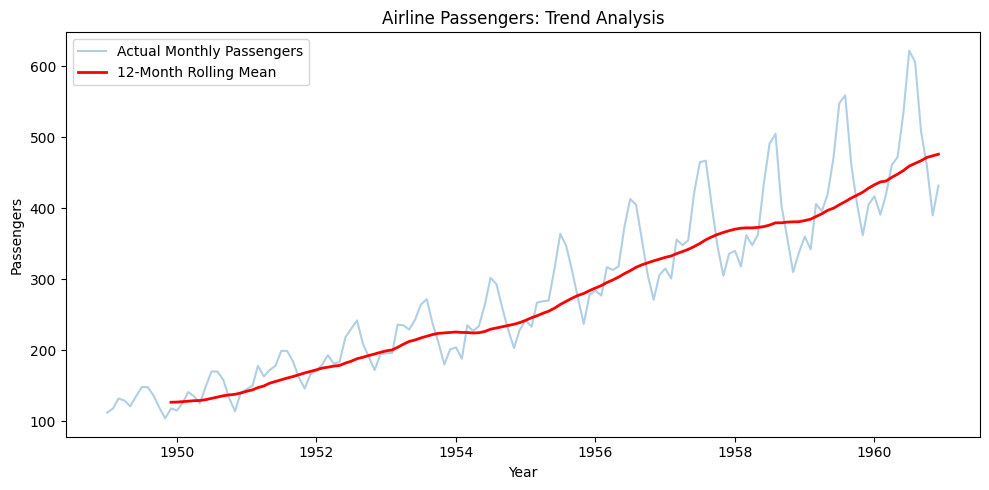

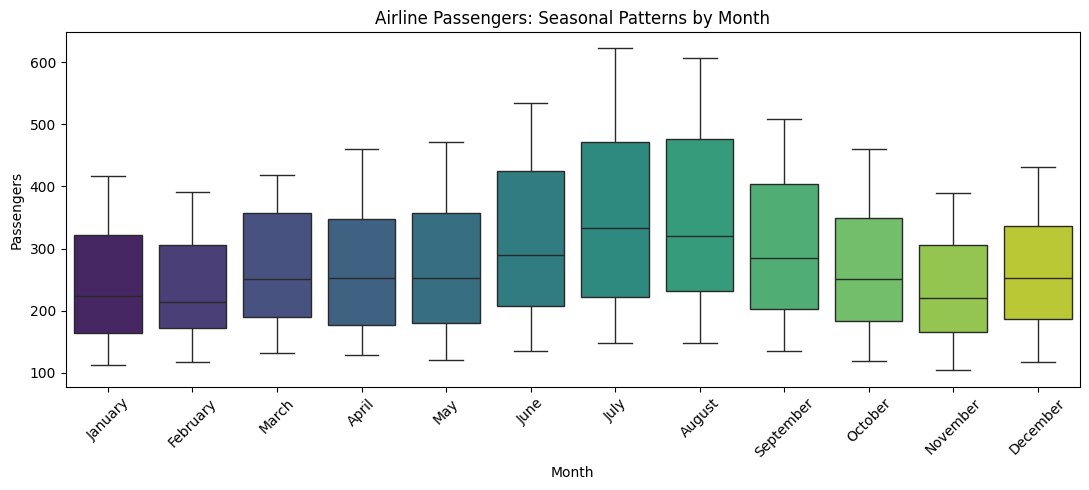

In [ ]:
""" 1. Write a program to perform time series visualization using Pandas and Matplotlib,
showing trends, seasonal patterns, and moving averages.
Given the "Airline Passengers" dataset (1949-1960), write a Python program to:
1. Pre-process the data by converting date strings into a DatetimeIndex.
2. Calculate a 12-month Rolling Mean to smooth out noise and visualize the growth
trend.
3. Generate a Seasonal Boxplot to identify recurring monthly fluctuations (Seasonality)."""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Prepare Data
url = "AirPassengers.csv"

df = pd.read_csv(url)
df.columns = ['Month', 'Passengers']

df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# 2. Moving Average (Trend) Calculation
df['12-MA'] = df['Passengers'].rolling(window=12).mean()

print(df.head(15))

# Visualization 1: Trend Analysis
plt.figure(figsize=(10, 5))
plt.plot(df['Passengers'], alpha=0.3, label='Actual Data (Monthly)')
plt.plot(df['12-MA'], color='red', label='12-Month Moving Avg (Trend)')
plt.title('Airline Passengers: Trend Analysis')
plt.legend()
plt.show()

# 3. Seasonal Patterns Analysis
df['Month_Name'] = df.index.month_name()

months = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='Month_Name',
    y='Passengers',
    order=months,
    hue='Month_Name',
    palette='viridis',
    legend=False
)

plt.title('Airline Passengers: Seasonal Patterns by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()